In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

RuntimeError: module compiled against API version 0xe but this version of numpy is 0xd

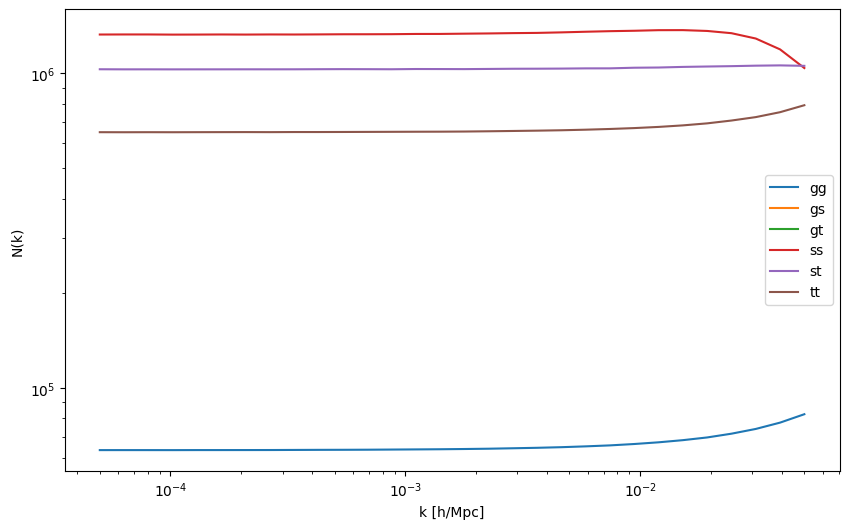

In [2]:
import pandas as pd

# Load results
df = pd.read_pickle('../output/desiasymm/data_dir/quadratic_results.pkl')

# Access specific results
k_values = df['K']

# Plot results
plt.figure(figsize=(10, 6))
r = {}

tr1, tr2 = "gal", "gal2"
for estimator_pair in ['gg', 'gs', 'gt', 'ss', 'st', 'tt']:
    key = f"{estimator_pair}_{tr1}{tr2}"
    if key in df:
        plt.loglog(df['K'], df[key]**-1., label=estimator_pair)
        r[estimator_pair] = (df['K'], df[key]**-1.)
plt.legend()
plt.xlabel('k [h/Mpc]')
plt.ylabel('N(k)')
plt.show()

In [4]:
from scipy.interpolate import UnivariateSpline
from scipy.integrate import quad

nome = "desiasymm"
directory = f"/home/users/d/darwish/quadraticrecforlss/example/output/{nome}/data_dir/"
Ns = {k: np.loadtxt(directory+f"{k}.txt").T for k in ["Ngg", "Nss", "Ntt", "Ngs", "Nst", "Ngt"]}
vals = {k: np.loadtxt(directory+f"values{k}.txt").T for k in ["gg", "ss", "tt"]}

linear_power = np.loadtxt(directory+"linear_power.txt").T
nonlinear_power = np.loadtxt(directory+"nonlinear_power.txt").T

knl, pnl = nonlinear_power
pnlf = UnivariateSpline(knl, pnl)

kl, pl = linear_power
plf = UnivariateSpline(knl, pl)
plf_loglog = UnivariateSpline(np.log(knl), np.log(pl))
pldf = plf_loglog.derivative(1)

fss = lambda k: k**2*plf(k)**2/pnlf(k)**2*(0.5+1/3*pldf(k))
fsg = lambda k: k**2*plf(k)**2/pnlf(k)**2*(-1-2/3*pldf(k))
fgg = lambda k: k**2*plf(k)**2/pnlf(k)**2

factor_ss = quad(fss, 0.051, 0.15)[0]
factor_sg = quad(fsg, 0.051, 0.15)[0]
factor_gg = quad(fgg, 0.051, 0.15)[0]
print(factor_sg/factor_ss, factor_ss/factor_sg)


b10 = 1.6
facss = factor_ss/b10**4*(2*np.pi)/(2*np.pi)**3*2

facgg = factor_gg/b10**4*(2*np.pi)/(2*np.pi)**3*2*2*8*(17/21)**2


-2.0 -0.5


In [208]:
from sympy import symbols, sqrt, integrate, legendre, simplify, expand, series, collect, limit, Symbol, Poly, together, apart, factor

def calculate_squeezed_limit(F_function, max_power=2, take_squeezed_limit=True, Ma = 1, Mb = 1, K = None, k = None, mu = None, P_k = None, Q_k = None):
    """
    Calculate the squeezed limit (K→0) for a general kernel function F.
    
    Parameters:
    -----------
    F_function : callable
        A function that takes (k1, k2, k1_mag, k2_mag, dot_product) and returns the kernel value
    max_power : int
        Maximum power of K/k to expand to
        
    Returns:
    --------
    The squeezed limit expression
    """
    # Define symbols
    #K, k, mu = symbols('K k mu')
    #P_k = symbols('P_k')  # Power spectrum
    #Q_k = symbols('Q_k')  # d ln P / d ln k
    small_param = K/k
    
    # Define Legendre polynomials
    P0 = 1
    P1 = mu
    P2 = (3*mu**2 - 1)/2
    
    # Case 1: F(K, k - K)
    k_minus_K_mag = sqrt(k**2 - 2*k*K*mu + K**2)
    K_dot_k_minus_K = K*(k*mu - K)
    
    F_case1 = Ma*F_function(K, None, K, k_minus_K_mag, K_dot_k_minus_K)
    
    # Case 2: F(K, -k)
    F_case2 = Mb*F_function(K, None, K, k, -K*k*mu)
    
    # Expand for small K/k
    try:
        # For Case 1 with sqrt term, expand carefully
        F_case1_subst = F_case1.subs(k, K/small_param)
        F_case1_series = series(F_case1_subst, small_param, 0, max_power).removeO()
        F_case1_expanded = F_case1_series.subs(small_param, K/k)
        F_case1_expanded = expand(F_case1_expanded)
        F_case1_expanded = collect(F_case1_expanded, K/k)
        
        # Express in terms of Legendre polynomials
        F_case1_legendre = F_case1_expanded.subs(mu**2, (2*P2 + 1)/3)
        F_case1_legendre = expand(F_case1_legendre)
        F_case1_legendre = collect(F_case1_legendre, [P0, P1, P2])
        
        # For Case 2
        F_case2_subst = F_case2.subs(k, K/small_param)
        F_case2_series = series(F_case2_subst, small_param, 0, max_power).removeO()
        F_case2_expanded = F_case2_series.subs(small_param, K/k)
        F_case2_expanded = expand(F_case2_expanded)
        F_case2_expanded = collect(F_case2_expanded, K/k)
        
        # Express in terms of Legendre polynomials
        F_case2_legendre = F_case2_expanded.subs(mu, P1)
        F_case2_legendre = collect(F_case2_legendre, [P0, P1, P2])
        
        # P(|K-k|) ≈ P(k)(1 - μ(K/k)Q(k))
        P_K_minus_k = P_k * (1 - mu * (K/k) * Q_k)
        
        # Combine the terms
        combination = 2 * (F_case1_legendre * P_K_minus_k + F_case2_legendre * P_k)
        combination = expand(combination)
        combination = collect(combination, [P0, P1, P2])

        combination_rational = together(combination)
        combination_parts = apart(combination_rational, K)

        terms = combination_parts.as_ordered_terms()
        inverse_K_terms = []
        regular_terms = []
        
        for term in terms:
            if 1/K in term.as_ordered_factors():
                inverse_K_terms.append(term)
            else:
                regular_terms.append(term)
        
        # Take the limit of only the regular terms
        if regular_terms:
            regular_part = sum(regular_terms)
            if take_squeezed_limit:
                regular_limit = limit(regular_part, K, 0)
            else:
                regular_limit = regular_part
        else:
            regular_limit = 0

         # Combine the results
        if inverse_K_terms:
            inverse_K_part = sum(inverse_K_terms)
            result = inverse_K_part + regular_limit
        else:
            result = regular_limit
        
        return result
        
    except Exception as e:
        return f"Error in calculation: {e}"
    
def integrate_over_mu(expr):
    return integrate(expr, (mu, -1, 1))

# Example usage with F_S from your code
def F_S(k1, k2, k1_mag, k2_mag, dot_product):
    return (1/2) * (1/k1_mag**2 + 1/k2_mag**2) * dot_product


def F_T(k1, k2, k1_mag, k2_mag, dot_product):
    return dot_product**2/(k1_mag**2*k2_mag**2)-1/3

def F_G(k1, k2, k1_mag, k2_mag, dot_product):
    return k1_mag/k1_mag


take_squeezed_limit = True

K = symbols('K')
k = symbols('k')
mu = symbols('mu')
P_k = symbols('P_k')
Q_k = symbols('Q_k')

from sympy import symbols, sqrt, integrate, legendre, simplify, expand, series, collect, limit, Symbol, Poly, together, apart, factor
import sympy as sp

def calculate_squeezed_limit_with_integration(F1_function, F2_function=None, max_power=2, take_squeezed_limit=True, Ma1=1, Mb1=1, Ma2=1, Mb2=1, K = None, k = None, mu = None, P_k = None, Q_k = None):
    """
    Calculate the squeezed limit for one or two kernel functions, multiply them,
    integrate over mu and k with the form:
    ∫dk k² ∫dμ combined_squeezed/2 * (PAA(k) * PBB(|K-k|))
    
    Parameters:
    -----------
    F1_function : callable
        First kernel function
    F2_function : callable or None
        Second kernel function (if None, only F1 is used)
    max_power : int
        Maximum power of K/k to expand to
    take_squeezed_limit : bool
        Whether to take the limit K→0 for regular terms
    Ma1, Mb1 : symbols or numbers
        Multipliers for the two cases of F1
    Ma2, Mb2 : symbols or numbers
        Multipliers for the two cases of F2
        
    Returns:
    --------
    The integrated result grouped by power spectrum terms
    """
    # Define symbols
    """K, k, mu = symbols('K k mu')
    P_k = symbols('P_k')  # Linear power spectrum
    Q_k = symbols('Q_k')  # d ln P / d ln k"""
    
    # Calculate squeezed limit for F1
    squeezed_limit_F1 = calculate_squeezed_limit(F1_function, max_power, take_squeezed_limit, Ma1, Mb1, K, k, mu, P_k, Q_k)
    
    # If F2 is provided, calculate its squeezed limit and multiply
    if F2_function is not None:
        squeezed_limit_F2 = calculate_squeezed_limit(F2_function, max_power, take_squeezed_limit, Ma2, Mb2, K, k, mu, P_k, Q_k)
        print("Print", squeezed_limit_F2)
        combined_squeezed = squeezed_limit_F1 * squeezed_limit_F2
    else:
        combined_squeezed = squeezed_limit_F1
    
    # Expand the combined result
    combined_squeezed = expand(combined_squeezed)
    
    # Define bias and shot noise terms
    bAA, bBB = symbols('b_AA b_BB')
    sA, sB = symbols('s_A s_B')
    Pnlin = symbols('P_nlin')  # Non-linear power spectrum
    Q_nlin = symbols('Q_nlin')  # d ln Pnlin / d ln k

    nhalo = 3.3e-4
    shot = 1.0 / nhalo

    sA, sB = shot, shot

    # Define the power spectra with bias and shot noise
    PAA = bAA**2 * Pnlin + sA
    PBB = bBB**2 * Pnlin + sB
    
    # For PBB(|K-k|), expand around k for small K
    # PBB(|K-k|) ≈ PBB(k) * (1 - μ(K/k)Q_nlin(k))
    PBB_K_minus_k = bBB**2 * Pnlin * (1 - mu * (K/k) * Q_nlin) + sB
    
    # Construct the integrand: combined_squeezed/2 * PAA(k) * PBB(|K-k|)
    integrand = combined_squeezed/2 /PAA / PBB_K_minus_k

    num, den = sp.fraction(integrand)
    
    #"""
    c = symbols('c')
    n = sp.Wild('n', properties=[lambda k: k > 0])
    pattern = K**(-n)
    new_numerator = num.replace(pattern, c**n)
    new_integrand = new_numerator/den
    new_integrand = limit(new_integrand, K, 0)
    pattern = c**(n)
    integrand = new_integrand.replace(pattern, 1/K**n)
    #"""

    # Integrate over mu
    mu_integrated = integrate(integrand, (mu, -1, 1))

    mu_integrated = simplify(mu_integrated)
    
    # Multiply by k² for the k integration
    k_integrand = k**2 * mu_integrated
    
    # Expand and collect terms
    k_integrand = expand(k_integrand)
    
    # Collect terms by powers of k to prepare for k integration
    k_integrand = collect(k_integrand, k)
    
    # We don't actually perform the k integration symbolically as it depends on the 
    # specific form of Pnlin(k), but we organize the terms for easier integration
    
    # Collect terms by Pnlin, shot noise, and their combinations
    result = collect(k_integrand, [Pnlin**2, Pnlin*sA, Pnlin*sB, sA*sB])

    #if take_squeezed_limit:
    #    result = limit(result, K, 0)
    #else:
    #    result = result
    
    return result.simplify()


def final_integrand(result):
    pi = symbols('pi')
    factor = 2*pi/(2*pi)**3*result
    return factor

In [230]:

def get_simple_integrand(F1_function, F2_function=None, max_power=2, take_squeezed_limit=True, Ma1=1, Mb1=1, Ma2=1, Mb2=1, K = None, k = None, mu = None, P_k = None, Q_k = None):
    """
    Calculate the squeezed limit for one or two kernel functions, multiply them,
    integrate over mu and k with the form:
    ∫dk k² ∫dμ combined_squeezed/2 * (PAA(k) * PBB(|K-k|))
    
    Parameters:
    -----------
    F1_function : callable
        First kernel function
    F2_function : callable or None
        Second kernel function (if None, only F1 is used)
    max_power : int
        Maximum power of K/k to expand to
    take_squeezed_limit : bool
        Whether to take the limit K→0 for regular terms
    Ma1, Mb1 : symbols or numbers
        Multipliers for the two cases of F1
    Ma2, Mb2 : symbols or numbers
        Multipliers for the two cases of F2
        
    Returns:
    --------
    The integrated result grouped by power spectrum terms
    """
    # Define symbols
    """K, k, mu = symbols('K k mu')
    P_k = symbols('P_k')  # Linear power spectrum
    Q_k = symbols('Q_k')  # d ln P / d ln k"""
    
    # Calculate squeezed limit for F1
    squeezed_limit_F1 = calculate_squeezed_limit(F1_function, max_power, take_squeezed_limit, Ma1, Mb1, K, k, mu, P_k, Q_k)
    
    # If F2 is provided, calculate its squeezed limit and multiply
    if F2_function is not None:
        squeezed_limit_F2 = calculate_squeezed_limit(F2_function, max_power, take_squeezed_limit, Ma2, Mb2, K, k, mu, P_k, Q_k)
        print("Print", squeezed_limit_F2)
        combined_squeezed = squeezed_limit_F1 * squeezed_limit_F2
    else:
        combined_squeezed = squeezed_limit_F1
    
    # Expand the combined result
    combined_squeezed = expand(combined_squeezed)
    
    # Define bias and shot noise terms
    bAA, bBB = symbols('b_AA b_BB')
    sA, sB = symbols('s_A s_B')
    Pnlin = symbols('P_nlin')  # Non-linear power spectrum
    Q_nlin = symbols('Q_nlin')  # d ln Pnlin / d ln k

    nhalo = 3.3e-4
    shot = 1.0 / nhalo

    sA, sB = shot, shot

    # Define the power spectra with bias and shot noise
    PAA = bAA**2 * Pnlin + sA
    PBB = bBB**2 * Pnlin + sB
    
    # For PBB(|K-k|), expand around k for small K
    # PBB(|K-k|) ≈ PBB(k) * (1 - μ(K/k)Q_nlin(k))
    PBB_K_minus_k = bBB**2 * Pnlin * (1 - mu * (K/k) * Q_nlin) + sB
    
    # Construct the integrand: combined_squeezed/2 * PAA(k) * PBB(|K-k|)
    integrand = combined_squeezed/2 /PAA / PBB_K_minus_k
    final_integrand_ = final_integrand(integrand)
    pi = symbols('pi')
    Ma_sym, Mb_sym = symbols('M_a M_b')    # Multiplier parameters
    from sympy import lambdify
    function = lambdify([k, mu, K, P_k, Pnlin, Q_k, Q_nlin, bAA, bBB, pi, Ma_sym, Mb_sym], 
                   final_integrand_, modules=['numpy'])
    return function


In [242]:
import s
from sympy import symbols

def F_S(k1, k2, k1_mag, k2_mag, dot_product):
    return (1/2) * (1/k1_mag**2 + 1/k2_mag**2) * dot_product

def F_T(k1, k2, k1_mag, k2_mag, dot_product):
    return dot_product**2/(k1_mag**2*k2_mag**2)*2/7 - 1/3

def F_G(k1, k2, k1_mag, k2_mag, dot_product):
    return k2_mag/k2_mag*17/21  # This is just 1, but keeping your original function

Ma, Mb = symbols('M_a M_b')
cases = {"s": (F_S, 1, 1), "t": (F_T, 1, 1), "g": (F_G, 1, 1), "x": (F_S, Ma, Mb)}

In [243]:
from sympy import symbols, lambdify
import numpy as np
from scipy.interpolate import UnivariateSpline
from scipy.integrate import quad

def evaluate_result(expr, linear_power, nonlinear_power, k_range=(0.01, 1.0), 
                   K_value=1e-4, bA=1.0, bB=1.0, Ma=1.0, Mb=1.0):
    """
    Evaluate a symbolic result using numerical power spectra, properly handling 1/K terms
    
    Parameters:
    -----------
    expr : sympy expression
        The symbolic expression to evaluate
    linear_power : tuple
        (k_array, P_L_array) for the linear power spectrum
    nonlinear_power : tuple
        (k_array, P_NL_array) for the nonlinear power spectrum
    k_range : tuple
        (k_min, k_max) for the integration range
    K_value : float
        Small value to use for K in 1/K terms
    bA, bB : float
        Bias parameters
    Ma, Mb : float
        Multiplier parameters
        
    Returns:
    --------
    tuple: (result, error) from numerical integration
    """
    # Define symbols for lambdify
    k, K = symbols('k K')
    P_k, P_nlin = symbols('P_k P_nlin')  # Power spectra
    Q_k, Q_nlin = symbols('Q_k Q_nlin')  # Derivatives
    b_AA, b_BB = symbols('b_AA b_BB')    # Bias parameters
    Ma_sym, Mb_sym = symbols('M_a M_b')    # Multiplier parameters
    pi = symbols('pi')
    
    # Create lambda function for the expression
    func = lambdify([k, K, P_k, P_nlin, Q_k, Q_nlin, b_AA, b_BB, Ma_sym, Mb_sym, pi], 
                   expr, modules=['numpy'])
    
    # Extract arrays
    knl, pnl = nonlinear_power
    kl, pl = linear_power
    
    # Create spline interpolations for power spectra
    pnlf = UnivariateSpline(knl, pnl, s=0)
    plf = UnivariateSpline(kl, pl, s=0)
    
    # Create log-log splines for derivatives
    plf_loglog = UnivariateSpline(np.log(kl), np.log(pl), s=0)
    pnlf_loglog = UnivariateSpline(np.log(knl), np.log(pnl), s=0)
    
    # Define the integrand function
    def integrand(k_val):
        # Evaluate power spectra at k
        P_L = plf(k_val)
        P_NL = pnlf(k_val)
        
        # Evaluate logarithmic derivatives
        dln_P_L_dlnk = plf_loglog.derivative(1)(np.log(k_val))
        dln_P_NL_dlnk = pnlf_loglog.derivative(1)(np.log(k_val))
        
        # Evaluate the lambda function
        return func(k_val, K_value, P_L, P_NL, dln_P_L_dlnk, dln_P_NL_dlnk, 
                   bA, bB, Ma, Mb, np.pi)
    
    # Perform the integration
    k_min, k_max = k_range
    result, error = quad(integrand, k_min, k_max)
    
    return result, error


In [244]:
knl, pnl = nonlinear_power
kl, pl = linear_power

from scipy.interpolate import UnivariateSpline
from scipy.integrate import quad

knl, pnl = nonlinear_power
pnlf = UnivariateSpline(knl, pnl)

kl, pl = linear_power
plf = UnivariateSpline(knl, pl)
plf_loglog = UnivariateSpline(np.log(knl), np.log(pl))
pnlf_loglog = UnivariateSpline(np.log(knl), np.log(pnl))
pldf = plf_loglog.derivative(1)
pnldf = pnlf_loglog.derivative(1)

Print -P_k*Q_k*mu**2 - P_k

s * s squeezed limit with μ integration:
500000000000000000000*P_k**2*k**2*(3*Q_k**2 + 10*Q_k + 15)/(3*pi**2*(10000000000000000000000*P_nlin**2*b_AA**2*b_BB**2 + 30303030303030300000000000*P_nlin*b_AA**2 + 30303030303030300000000000*P_nlin*b_BB**2 + 91827364554637263544536271809))
Print 8*P_k*mu**2/7 - 4*P_k/3

t * t squeezed limit with μ integration:
376000000000000000000000*P_k**2*k**2/(147*pi**2*(10000000000000000000000*P_nlin**2*b_AA**2*b_BB**2 + 30303030303030300000000000*P_nlin*b_AA**2 + 30303030303030300000000000*P_nlin*b_BB**2 + 91827364554637263544536271809))
Print 68*P_k/21

g * g squeezed limit with μ integration:
11560000000000000000000000*P_k**2*k**2/(441*pi**2*(10000000000000000000000*P_nlin**2*b_AA**2*b_BB**2 + 30303030303030300000000000*P_nlin*b_AA**2 + 30303030303030300000000000*P_nlin*b_BB**2 + 91827364554637263544536271809))
Print -M_a*P_k*Q_k*mu**2 - M_a*P_k + 1.0*P_k*k*mu*(M_a - M_b)/K

x * x squeezed limit with μ integration:
5000000000

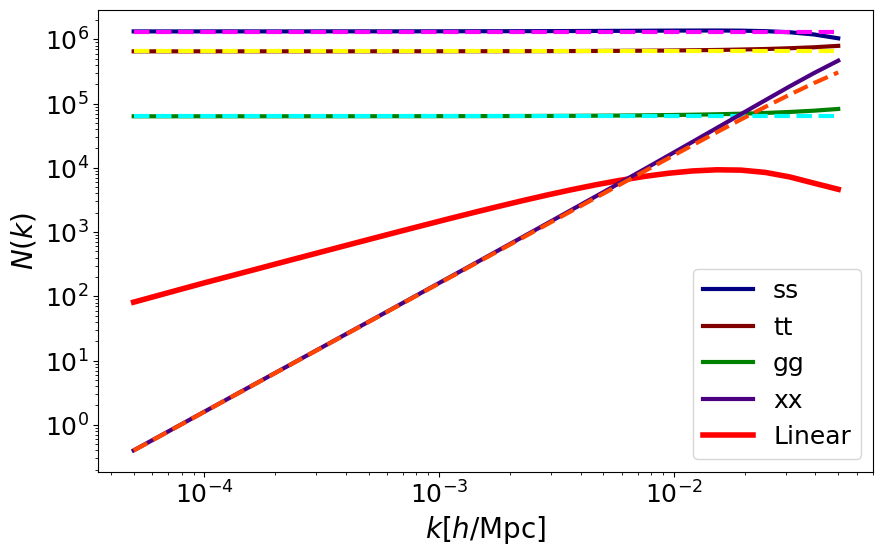

In [274]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df = pd.read_pickle('../output/desiasymm/data_dir/quadratic_results.pkl')

estimators = ["s", "t", "g", "x"]

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# Set the global font to be DejaVu Sans, size 10
plt.rc('font', family='DejaVu Sans', size=10)

# Set the font scale for different elements
plt.rc('axes', titlesize=14, labelsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('legend', fontsize=10)
plt.rc('figure', titlesize=16)

solid_colors = ['#000080', '#800000', '#008000', '#4B0082', '#2F4F4F']  # Navy, maroon, green, indigo, dark slate
dashed_colors = ['#FF00FF', '#FFFF00', '#00FFFF', '#FF4500', '#7FFF00']  # Magenta, yellow, cyan, orange-red, chartreuse

cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)


for i, e in enumerate(estimators):
    fixed = e
    vary = [e] #["S", "T", "G", "X"]

    K, k, mu, P_k, Q_k = symbols('K k mu P_k Q_k')

    results = {}
    results_latex = {}
    for v in vary:
        #fun = get_simple_integrand(cases[fixed][0], cases[v][0], take_squeezed_limit = True, Ma1 = cases[fixed][1], Mb1 = cases[fixed][2], Ma2 = cases[v][1], Mb2 = cases[v][2], K = K, k = k, mu = mu, P_k = P_k, Q_k = Q_k)
        result = calculate_squeezed_limit_with_integration(cases[fixed][0], cases[v][0], take_squeezed_limit = True, Ma1 = cases[fixed][1], Mb1 = cases[fixed][2], Ma2 = cases[v][1], Mb2 = cases[v][2], K = K, k = k, mu = mu, P_k = P_k, Q_k = Q_k)
        print(f"\n{fixed} * {v} squeezed limit with μ integration:")
        result = final_integrand(result)
        #result = float_to_rational(result)
        print(result)
        results[f"{fixed}-{v}"] = result

    check = []
    check_swap = []
    bA, bB = 1.6, 1.6
    for K in df['K']:
        Ma, Mb = 1.0, 0.0
        r = evaluate_result(results[f"{e}-{e}"], linear_power, nonlinear_power, k_range=(0.051, 0.15), 
                        K_value=K, bA=bA, bB=bB, Ma=Ma, Mb=Mb)[0]
        r_swap = evaluate_result(results[f"{e}-{e}"], linear_power, nonlinear_power, k_range=(0.051, 0.15), 
                        K_value=K, bA=bA, bB=bB, Ma=Mb, Mb=Ma)[0]
        check.append(r)
        check_swap.append(r_swap)
    check = np.array(check)
    check_swap = np.array(check_swap)

    estimator_pair = f"{e}{e}"
    key = f"{estimator_pair}_{tr1}{tr2}"
    Naa = df[key]**-1.
    plt.loglog(df['K'], Naa, label=estimator_pair, color = solid_colors[i], lw = 3)
    plt.plot(df['K'], (check)**-1., ls = "--", color = dashed_colors[i], lw = 3)
    #plt.plot(df['K'], (check_swap)**-1., ls = "--", color = colors[i], lw = 3)
plt.plot(df['K'], np.interp(df['K'], kl, pl), label = "Linear", ls = "-", color = "red", zorder = 0, lw = 4)
plt.legend(fontsize = 18)
plt.xlabel('$k [h/\mathrm{Mpc}]$', fontsize = 20)
plt.ylabel('$N(k)$', fontsize = 20)
plt.xscale("log")
plt.tick_params(axis='both', which='major', labelsize=18)
plt.savefig(f"ns.pdf", dpi = 300)
plt.show()

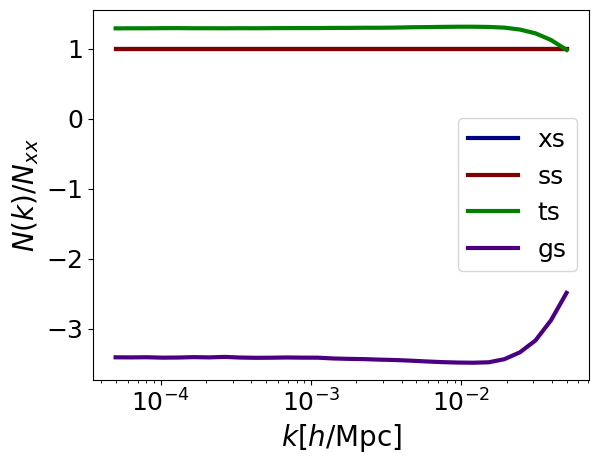

In [ ]:
import matplotlib.font_manager as fm
slick_font = 'Helvetica Neue' if 'Helvetica Neue' in fm.findSystemFonts() else 'DejaVu Sans'
plt.rc('font', family=slick_font, size=11)
plt.rc('axes', titlesize=16, labelsize=14, linewidth=0.8)  # Thinner axes lines


estimators = ["x", "s", "t", "g"]
for i, e in enumerate(estimators):
    fixed = "s"
    try:
        estimator_pair = f"{e}{fixed}"
        key = f"{estimator_pair}_{tr1}{tr2}"
        integral = df[key]
    except:
        estimator_pair = f"{fixed}{e}"
        key = f"{estimator_pair}_{tr1}{tr2}"
        integral = df[key]

    if e == fixed:
        Nxx = integral**-1.
    plt.plot(df['K'], integral*Nxx, label = f"{e}{fixed}", color = solid_colors[i], lw = 3)
    
plt.legend(fontsize = 18)
plt.xlabel('$k [h/\mathrm{Mpc}]$', fontsize = 20)
plt.ylabel('$N(k)/N_{xx}$', fontsize = 20)
plt.xscale("log")
plt.tick_params(axis='both', which='major', labelsize=18)
plt.savefig(f"ns.pdf", dpi = 300)
plt.show()